Loaded model: models/frf_model_full.pt
Feature tokens: ['f', 'damage']


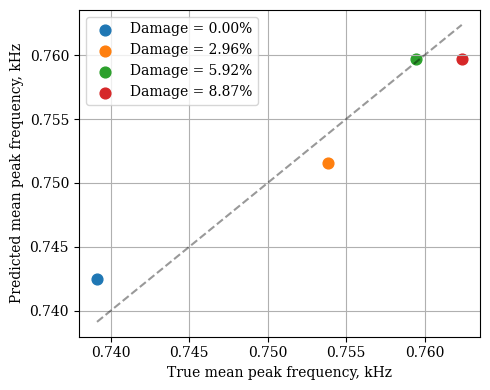

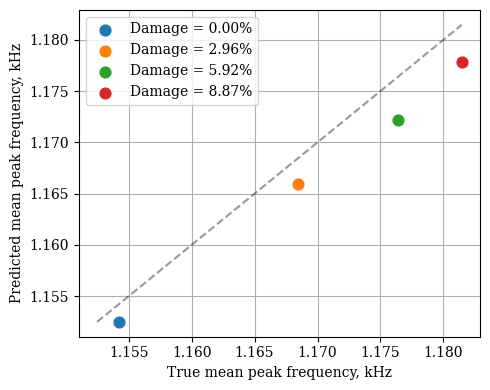

In [17]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Dict, List

import dill
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import sympy as sp


# ============================================================
# Matplotlib config
# ============================================================

mpl.rcParams["font.family"] = "serif"


# ============================================================
# CONFIG
# ============================================================

N_PEAKS = 2

PEAK_CENTERS = [0.75, 1.18]  # kHz
PEAK_WINDOW = 0.1            # kHz

DAMAGE_LEVEL = {
    "healthy": 0.0,
    "damage_2.96": 2.96,
    "damage_5.92": 5.92,
    "damage_8.87": 8.87,
}

ROOT = Path.cwd()
DATA = ROOT / "frf_data"
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

FRF_FOLDERS = {
    "healthy": DATA / "1-Beam_healthy",
    "damage_2.96": DATA / "2-Beam_damage_2.96",
    "damage_5.92": DATA / "3-Beam_damage_5.92",
    "damage_8.87": DATA / "4-Beam_damage_8.87",
}

MODEL_PATH = Path("models/frf_model_full.pt")

device = torch.device("cpu")


# ============================================================
# Load model
# ============================================================

ckpt = torch.load(
    MODEL_PATH,
    map_location=device,
    pickle_module=dill,
    weights_only=False,
)

model = ckpt["model"].to(device)
model.eval()

FEATURE_TOKENS: List[str] = ckpt["feature_tokens"]

print("Loaded model:", MODEL_PATH)
print("Feature tokens:", FEATURE_TOKENS)


# ============================================================
# Robust FRF reader
# ============================================================

_NUM = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?")


def read_frf_txt(path: Path):

    text = path.read_bytes().decode("latin-1", errors="ignore")

    f_list, m_list, p_list = [], [], []

    for line in text.splitlines():

        line = line.strip()
        if not line:
            continue

        nums = _NUM.findall(line)
        if len(nums) < 3:
            continue

        f = float(nums[0])
        mag = float(nums[1])
        ph = float(nums[2])

        if not (np.isfinite(f) and np.isfinite(mag) and np.isfinite(ph)):
            continue

        f_list.append(f)
        m_list.append(mag)
        p_list.append(ph)

    f = np.asarray(f_list)
    mag = np.asarray(m_list)
    ph = np.asarray(p_list)

    idx = np.argsort(f)

    return f[idx], mag[idx], ph[idx]


# ============================================================
# Feature builder
# ============================================================

def db_to_linear_mag(mag_db: np.ndarray):
    return np.power(10.0, mag_db / 20.0)


def build_feature_matrix(f, mag_db, ph_deg, cond):

    phi = np.deg2rad(ph_deg)

    sinp = np.sin(phi)
    cosp = np.cos(phi)

    damage = DAMAGE_LEVEL[cond]

    feature_bank = {
        "f": (f / 1000.0).astype(np.float32),
        "sin_phase": sinp.astype(np.float32),
        "cos_phase": cosp.astype(np.float32),
        "damage": np.full_like(f, damage, dtype=np.float32),
    }

    X = np.concatenate(
        [feature_bank[t].reshape(-1, 1) for t in FEATURE_TOKENS],
        axis=1,
    ).astype(np.float32)

    y = db_to_linear_mag(mag_db).astype(np.float32)

    return X, y


# ============================================================
# Model prediction
# ============================================================

def predict_curve(fp: Path, cond: str):

    f, mag_db, ph_deg = read_frf_txt(fp)

    X, y_true = build_feature_matrix(f, mag_db, ph_deg, cond)

    with torch.no_grad():

        Xc = torch.from_numpy(X).float().to(device)

        pred = model(Xc).real

        y_pred = pred.detach().cpu().numpy().reshape(-1)

    f_idx = FEATURE_TOKENS.index("f")

    freq = X[:, f_idx]

    return freq, y_true, y_pred


# ============================================================
# Fixed-window peak detection
# ============================================================

def detect_matched_peaks(freq, y_true, y_pred):

    true_peaks = []
    pred_peaks = []

    for center in PEAK_CENTERS:

        mask = np.abs(freq - center) <= PEAK_WINDOW

        if not np.any(mask):
            true_peaks.append(np.nan)
            pred_peaks.append(np.nan)
            continue

        local_freq = freq[mask]
        local_true = y_true[mask]
        local_pred = y_pred[mask]

        t_idx = np.argmax(local_true)
        p_idx = np.argmax(local_pred)

        true_peaks.append(local_freq[t_idx])
        pred_peaks.append(local_freq[p_idx])

    return np.array(true_peaks), np.array(pred_peaks)


# ============================================================
# Collect peaks
# ============================================================

true_peaks_by_damage: Dict[str, List[np.ndarray]] = {}
pred_peaks_by_damage: Dict[str, List[np.ndarray]] = {}

for cond, folder in FRF_FOLDERS.items():

    true_peaks_by_damage[cond] = []
    pred_peaks_by_damage[cond] = []

    for fp in sorted(folder.glob("*.txt")):

        f, y_true, y_pred = predict_curve(fp, cond)

        p_true, p_pred = detect_matched_peaks(f, y_true, y_pred)

        true_peaks_by_damage[cond].append(p_true)
        pred_peaks_by_damage[cond].append(p_pred)


# ============================================================
# Mean peak frequencies
# ============================================================

mean_true = {}
mean_pred = {}

for cond in FRF_FOLDERS.keys():

    t = np.vstack(true_peaks_by_damage[cond])
    p = np.vstack(pred_peaks_by_damage[cond])

    mean_true[cond] = np.nanmean(t, axis=0)
    mean_pred[cond] = np.nanmean(p, axis=0)


# ============================================================
# Scatter plots PER PEAK
# ============================================================

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for peak_idx in range(N_PEAKS):

    plt.figure(figsize=(5, 4))

    true_vals = []
    pred_vals = []

    for i, cond in enumerate(FRF_FOLDERS.keys()):

        true_val = mean_true[cond][peak_idx]
        pred_val = mean_pred[cond][peak_idx]

        true_vals.append(true_val)
        pred_vals.append(pred_val)

        damage_value = DAMAGE_LEVEL[cond]

        plt.scatter(
            true_val,
            pred_val,
            color=default_colors[i],
            s=60,
            label=f"Damage = {damage_value:.2f}%",
        )

    true_vals = np.array(true_vals)
    pred_vals = np.array(pred_vals)

    min_v = min(true_vals.min(), pred_vals.min())
    max_v = max(true_vals.max(), pred_vals.max())

    plt.plot(
        [min_v, max_v],
        [min_v, max_v],
        linestyle="--",
        alpha=0.4,
        color="black",
    )

    plt.xlabel("True mean peak frequency, kHz")
    plt.ylabel("Predicted mean peak frequency, kHz")

    plt.grid(True)
    plt.legend()

    plt.tight_layout()

    save_path = FIGURES / f"peak_{peak_idx+1}_pred_vs_true.pdf"
    plt.savefig(save_path)

    plt.show()